# Consumer Shopping Behavior Analysis & Prediction

## Project Overview

**Dataset:** Consumer Behavior and Shopping Habits Dataset  
**Source:** [Kaggle - Consumer Behavior and Shopping Habits](https://www.kaggle.com/datasets/zeesolver/consumer-behavior-and-shopping-habits-dataset/data)  
**Records:** 3,900 transactions | **Features:** 18 columns

## Problem Statement

We approach this dataset with **two ML tasks**:

1. **Classification:** Predict whether a customer is a subscriber (`Subscription Status`) based on their demographics, purchase behavior, and transaction details.
2. **Regression:** Predict the `Purchase Amount (USD)` a customer will spend.

## Project Structure

| Section | Description |
|---------|-------------|
| 1. Setup & Data Loading | Imports, loading, initial inspection |
| 2. Data Cleaning & Validation | Missing values, duplicates, data types, outliers |
| 3. Exploratory Data Analysis | Statistical tests, distributions, feature-target relationships |
| 4. Feature Engineering | Encoding, transformations, pipeline design |
| 5. Task 1 — Classification | Subscription Status prediction with multiple models |
| 6. Task 2 — Regression | Purchase Amount prediction with multiple models |
| 7. Model Interpretation | SHAP values, feature importance analysis |
| 8. Conclusions & Lessons Learned | Findings, limitations, and honest assessment |

> **Note on Dataset Quality:** This is a synthetic/generated dataset with artificially uniform distributions. We acknowledge this upfront — the goal is to demonstrate **correct ML methodology** even when the underlying data has limited predictive signal.

## 1. Setup & Data Loading

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Pipelines
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score, ConfusionMatrixDisplay
)

# Model Interpretation
import shap

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('muted')

print("All libraries imported successfully.")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

All libraries imported successfully.
pandas: 3.0.2
numpy: 2.4.4


In [2]:
# Load dataset
df = pd.read_csv('shopping_behavior.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print()
df.head()

Dataset shape: (3900, 18)
Rows: 3,900 | Columns: 18



,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# Comprehensive data overview
print("=" * 60)
print("DATA TYPES & NON-NULL COUNTS")
print("=" * 60)
df.info()
print()

# Identify column types
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

DATA TYPES & NON-NULL COUNTS
<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used       

## 2. Data Cleaning & Validation

### 2.1 Missing Values & Duplicates

Before any analysis, we check for data quality issues systematically.

In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print("Missing Values Report:")
print(missing_report[missing_report['Missing Count'] > 0] if missing.sum() > 0 
      else "No missing values found.")
print()

# Duplicates
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Check for duplicate Customer IDs (should be unique)
dup_ids = df['Customer ID'].duplicated().sum()
print(f"Duplicate Customer IDs: {dup_ids}")

Missing Values Report:
No missing values found.

Duplicate rows: 0
Duplicate Customer IDs: 0


### 2.2 Outlier Detection

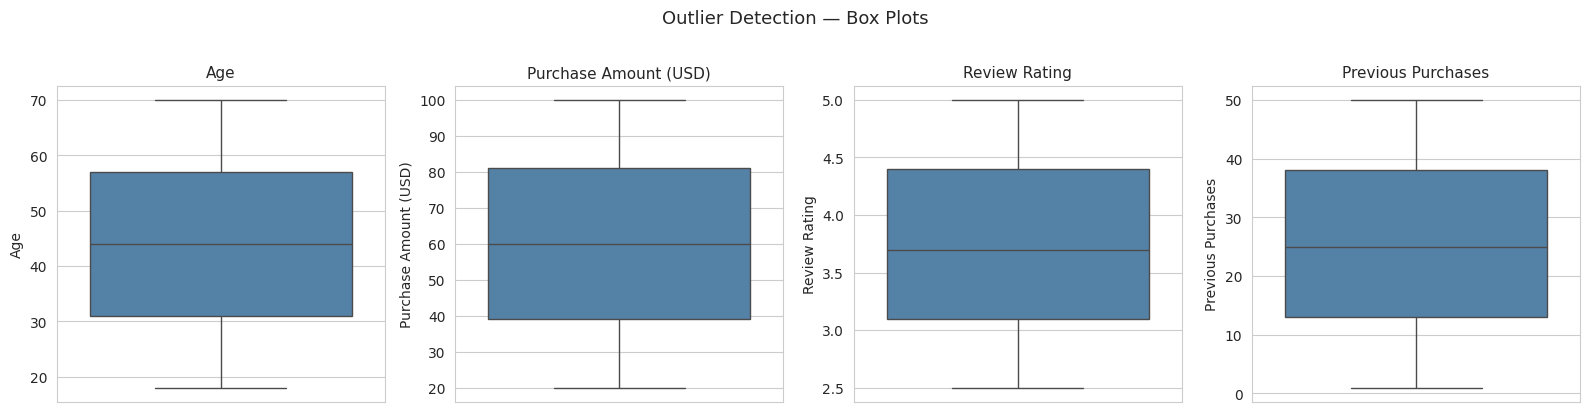


Outlier Report (IQR Method):
                         Q1    Q3   IQR  Lower Bound  Upper Bound  Outlier Count
Age                    31.0  57.0  26.0        -8.00        96.00            0.0
Purchase Amount (USD)  39.0  81.0  42.0       -24.00       144.00            0.0
Review Rating           3.1   4.4   1.3         1.15         6.35            0.0
Previous Purchases     13.0  38.0  25.0       -24.50        75.50            0.0


In [5]:
# Outlier detection using IQR method for all numerical features
# (excluding Customer ID which is just an identifier)

numerical_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

outlier_report = {}
for i, col in enumerate(numerical_features):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_report[col] = {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': len(outliers)
    }
    
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Outlier Detection — Box Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

outlier_df = pd.DataFrame(outlier_report).T
print("\nOutlier Report (IQR Method):")
print(outlier_df.to_string())

### 2.3 Data Quality Assessment

Let's check for suspicious patterns that might indicate synthetic data.

In [6]:
# Distribution uniformity checks
print("=" * 60)
print("DISTRIBUTION UNIFORMITY CHECK")
print("=" * 60)
print("\nIf distributions are suspiciously uniform, the data may be synthetic.\n")

for col in categorical_cols:
    vc = df[col].value_counts()
    cv = vc.std() / vc.mean()  # Coefficient of variation
    print(f"{col}: {df[col].nunique()} unique values, CV={cv:.3f}")
    if cv < 0.05:
        print(f"  ⚠ Very uniform distribution (CV < 0.05) — likely synthetic")
    print()

# Numerical distribution checks
print("Numerical Features — Skewness & Kurtosis:")
for col in numerical_features:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"  {col}: skew={skew:.4f}, kurtosis={kurt:.4f}")

print("\n⚠ FINDING: Most features show suspiciously uniform distributions.")
print("  Purchase Amount has near-zero skew and negative kurtosis (flat/uniform).")
print("  This is characteristic of synthetic data, not real e-commerce transactions.")
print("  We proceed with proper methodology, but acknowledge limited real-world signal.")

DISTRIBUTION UNIFORMITY CHECK

If distributions are suspiciously uniform, the data may be synthetic.

Gender: 2 unique values, CV=0.509

Item Purchased: 25 unique values, CV=0.072

Category: 4 unique values, CV=0.653

Location: 50 unique values, CV=0.105

Size: 4 unique values, CV=0.595

Color: 25 unique values, CV=0.073

Season: 4 unique values, CV=0.019
  ⚠ Very uniform distribution (CV < 0.05) — likely synthetic

Subscription Status: 2 unique values, CV=0.651

Shipping Type: 6 unique values, CV=0.024
  ⚠ Very uniform distribution (CV < 0.05) — likely synthetic

Discount Applied: 2 unique values, CV=0.198

Promo Code Used: 2 unique values, CV=0.198

Payment Method: 6 unique values, CV=0.041
  ⚠ Very uniform distribution (CV < 0.05) — likely synthetic

Frequency of Purchases: 7 unique values, CV=0.030
  ⚠ Very uniform distribution (CV < 0.05) — likely synthetic

Numerical Features — Skewness & Kurtosis:
  Age: skew=-0.0064, kurtosis=-1.1951
  Purchase Amount (USD): skew=0.0127, kurtos

### 2.4 Feature Redundancy Check

In [7]:
# Check if Discount Applied and Promo Code Used are identical
identical = (df['Discount Applied'] == df['Promo Code Used']).all()
print(f"'Discount Applied' and 'Promo Code Used' are identical: {identical}")

if identical:
    print("→ Dropping 'Promo Code Used' as it's a perfect duplicate of 'Discount Applied'.")
    df = df.drop(columns=['Promo Code Used'])
    
# Check relationship: Subscription Status ↔ Discount Applied
ct = pd.crosstab(df['Subscription Status'], df['Discount Applied'])
print("\nCrosstab — Subscription Status vs Discount Applied:")
print(ct)
print("\n⚠ FINDING: All subscribers (Yes) received discounts.")
print("  All Females are non-subscribers.")
print("  'Discount Applied' would leak Subscription Status — must handle carefully.")

'Discount Applied' and 'Promo Code Used' are identical: True
→ Dropping 'Promo Code Used' as it's a perfect duplicate of 'Discount Applied'.

Crosstab — Subscription Status vs Discount Applied:
Discount Applied       No   Yes
Subscription Status            
No                   2223   624
Yes                     0  1053

⚠ FINDING: All subscribers (Yes) received discounts.
  All Females are non-subscribers.
  'Discount Applied' would leak Subscription Status — must handle carefully.


In [8]:
# Drop identifier column
df = df.drop(columns=['Customer ID'])

# Drop Item Purchased — perfectly encodes Category (data leakage risk)
# Each item maps to exactly one category, making it a direct proxy
print("Dropping 'Item Purchased' — each item maps 1:1 to a Category.")
print("Using it to predict Category would be trivial data leakage.")
item_category_map = df.groupby('Item Purchased')['Category'].first()
print(f"\nItem → Category mapping (sample):")
print(item_category_map.head(10))

df = df.drop(columns=['Item Purchased'])

print(f"\nCleaned dataset shape: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Dropping 'Item Purchased' — each item maps 1:1 to a Category.
Using it to predict Category would be trivial data leakage.

Item → Category mapping (sample):
Item Purchased
Backpack    Accessories
Belt        Accessories
Blouse         Clothing
Boots          Footwear
Coat          Outerwear
Dress          Clothing
Gloves      Accessories
Handbag     Accessories
Hat         Accessories
Hoodie         Clothing
Name: Category, dtype: str

Cleaned dataset shape: (3900, 15)
Remaining columns: ['Age', 'Gender', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


## 3. Exploratory Data Analysis

### 3.1 Target Variable Analysis

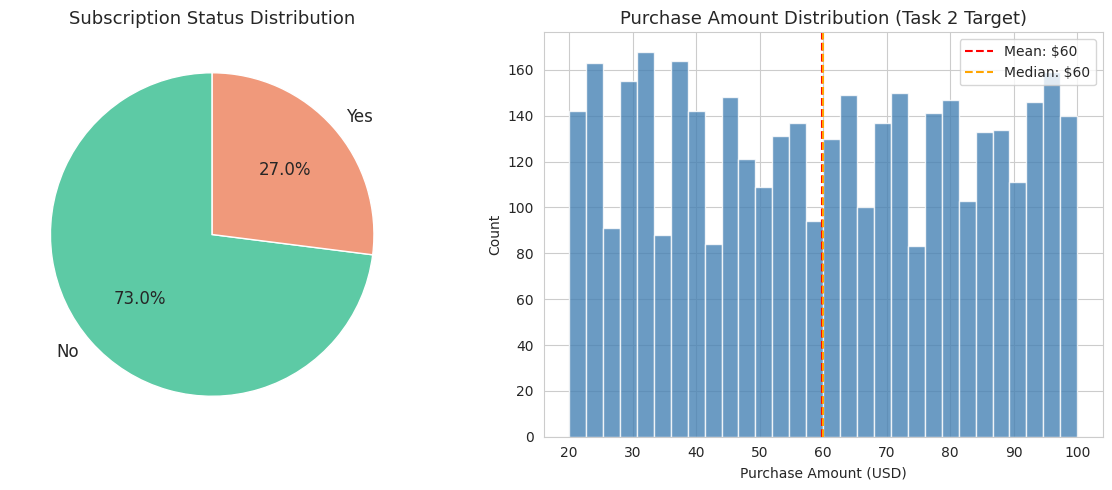

Subscription Status class balance:
  No:  2,847 (73.0%)
  Yes: 1,053 (27.0%)

Class imbalance ratio: 2.7:1


In [9]:
# Task 1 target: Subscription Status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subscription distribution
sub_counts = df['Subscription Status'].value_counts()
colors = ['#5DCAA5', '#F0997B']
axes[0].pie(sub_counts.values, labels=sub_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Subscription Status Distribution', fontsize=13)

# Purchase Amount distribution
axes[1].hist(df['Purchase Amount (USD)'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(df['Purchase Amount (USD)'].mean(), color='red', linestyle='--', label=f"Mean: ${df['Purchase Amount (USD)'].mean():.0f}")
axes[1].axvline(df['Purchase Amount (USD)'].median(), color='orange', linestyle='--', label=f"Median: ${df['Purchase Amount (USD)'].median():.0f}")
axes[1].set_xlabel('Purchase Amount (USD)')
axes[1].set_ylabel('Count')
axes[1].set_title('Purchase Amount Distribution (Task 2 Target)', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Subscription Status class balance:")
print(f"  No:  {sub_counts['No']:,} ({sub_counts['No']/len(df)*100:.1f}%)")
print(f"  Yes: {sub_counts['Yes']:,} ({sub_counts['Yes']/len(df)*100:.1f}%)")
print(f"\nClass imbalance ratio: {sub_counts['No']/sub_counts['Yes']:.1f}:1")

### 3.2 Feature-Target Relationships

In [10]:
# Statistical tests: which features actually relate to Subscription Status?
from scipy.stats import chi2_contingency, mannwhitneyu

print("=" * 60)
print("STATISTICAL SIGNIFICANCE TESTS — Subscription Status")
print("=" * 60)
print("\nChi-Square tests for categorical features:\n")

cat_features = ['Gender', 'Category', 'Size', 'Season', 'Shipping Type',
                'Payment Method', 'Frequency of Purchases', 'Color', 'Location']

chi2_results = []
for col in cat_features:
    ct = pd.crosstab(df[col], df['Subscription Status'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    chi2_results.append({'Feature': col, 'Chi2': round(chi2, 2), 'p-value': f'{p:.4f}', 'Significance': sig})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
print(chi2_df.to_string(index=False))

print("\nMann-Whitney U tests for numerical features:\n")
for col in numerical_features:
    group_yes = df[df['Subscription Status'] == 'Yes'][col]
    group_no = df[df['Subscription Status'] == 'No'][col]
    stat, p = mannwhitneyu(group_yes, group_no, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {col}: U={stat:.0f}, p={p:.4f} {sig}")

print("\n⚠ KEY FINDING: Gender is overwhelmingly significant (all Females are non-subscribers).")
print("  Most other features show weak or no statistical significance.")

STATISTICAL SIGNIFICANCE TESTS — Subscription Status

Chi-Square tests for categorical features:

               Feature   Chi2 p-value Significance
                Gender 676.79  0.0000          ***
              Location  42.41  0.7355           ns
                 Color  19.16  0.7432           ns
         Shipping Type   6.30  0.2781           ns
Frequency of Purchases   3.89  0.6909           ns
        Payment Method   3.86  0.5699           ns
              Category   1.34  0.7186           ns
                  Size   0.93  0.8191           ns
                Season   0.62  0.8910           ns

Mann-Whitney U tests for numerical features:

  Age: U=1511611, p=0.6849 ns
  Purchase Amount (USD): U=1485458, p=0.6657 ns
  Review Rating: U=1486974, p=0.7011 ns
  Previous Purchases: U=1559460, p=0.0525 ns

⚠ KEY FINDING: Gender is overwhelmingly significant (all Females are non-subscribers).
  Most other features show weak or no statistical significance.


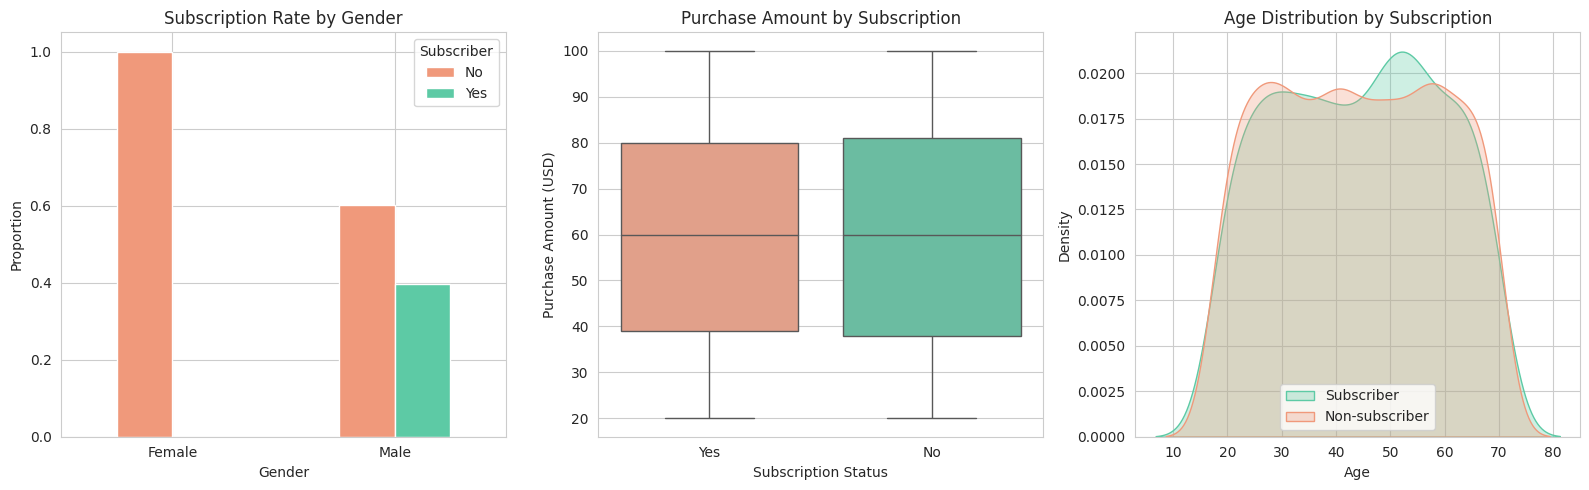

In [11]:
# Visual: Gender is the dominant predictor of subscription
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender vs Subscription
ct_gender = pd.crosstab(df['Gender'], df['Subscription Status'], normalize='index')
ct_gender.plot(kind='bar', ax=axes[0], color=['#F0997B', '#5DCAA5'], edgecolor='white')
axes[0].set_title('Subscription Rate by Gender', fontsize=12)
axes[0].set_ylabel('Proportion')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Subscriber')

# Purchase Amount by Subscription (very similar — weak signal)
sns.boxplot(x='Subscription Status', y='Purchase Amount (USD)', data=df, 
            ax=axes[1], palette=['#F0997B', '#5DCAA5'])
axes[1].set_title('Purchase Amount by Subscription', fontsize=12)

# Age distribution by Subscription
sns.kdeplot(data=df[df['Subscription Status']=='Yes'], x='Age', ax=axes[2], 
            label='Subscriber', color='#5DCAA5', fill=True, alpha=0.3)
sns.kdeplot(data=df[df['Subscription Status']=='No'], x='Age', ax=axes[2], 
            label='Non-subscriber', color='#F0997B', fill=True, alpha=0.3)
axes[2].set_title('Age Distribution by Subscription', fontsize=12)
axes[2].legend()

plt.tight_layout()
plt.show()

### 3.3 Correlation Analysis

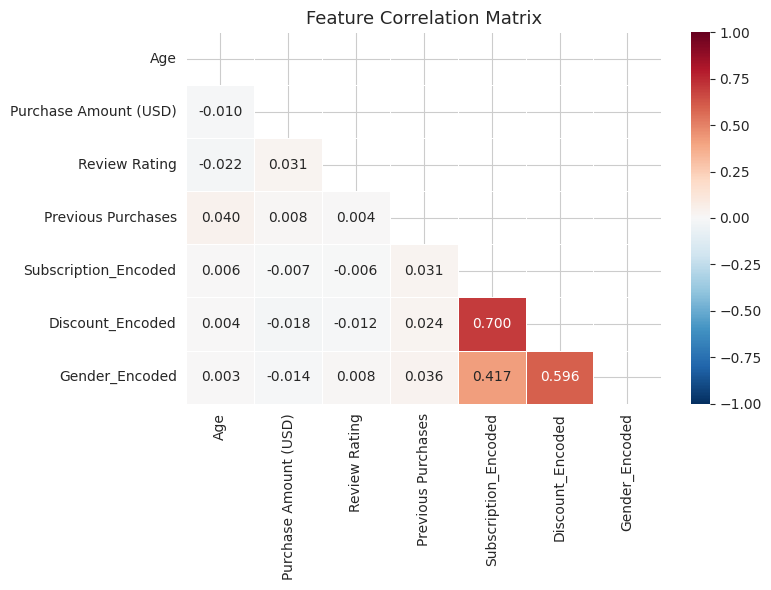

Key correlations with Subscription Status:
  Discount_Encoded: 0.700
  Gender_Encoded: 0.417
  Previous Purchases: 0.031
  Purchase Amount (USD): -0.007
  Age: 0.006
  Review Rating: -0.006


In [12]:
# Correlation heatmap for numerical features
# First encode binary features for correlation
df_corr = df.copy()
df_corr['Subscription_Encoded'] = (df_corr['Subscription Status'] == 'Yes').astype(int)
df_corr['Discount_Encoded'] = (df_corr['Discount Applied'] == 'Yes').astype(int)
df_corr['Gender_Encoded'] = (df_corr['Gender'] == 'Male').astype(int)

corr_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases',
             'Subscription_Encoded', 'Discount_Encoded', 'Gender_Encoded']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print("Key correlations with Subscription Status:")
subs_corr = corr_matrix['Subscription_Encoded'].drop('Subscription_Encoded').sort_values(key=abs, ascending=False)
for feat, val in subs_corr.items():
    print(f"  {feat}: {val:.3f}")

### 3.4 Category & Seasonal Analysis

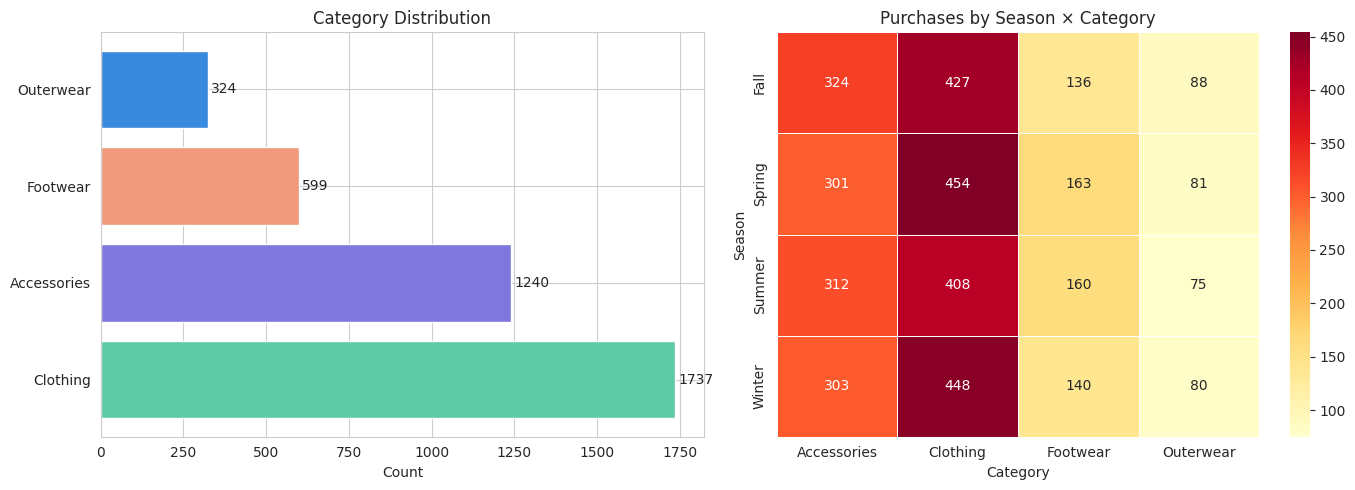

Observation: Purchases are remarkably evenly distributed across seasons
and categories — another sign of synthetic data generation.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category distribution
cat_counts = df['Category'].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color=['#5DCAA5', '#7F77DD', '#F0997B', '#378ADD'])
axes[0].set_xlabel('Count')
axes[0].set_title('Category Distribution', fontsize=12)
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=10)

# Season × Category heatmap
season_cat = pd.crosstab(df['Season'], df['Category'])
sns.heatmap(season_cat, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Purchases by Season × Category', fontsize=12)

plt.tight_layout()
plt.show()

print("Observation: Purchases are remarkably evenly distributed across seasons")
print("and categories — another sign of synthetic data generation.")

## 4. Feature Engineering

### 4.1 Design Decisions

Based on our EDA findings, here's our encoding strategy:

| Feature Type | Features | Encoding Method | Rationale |
|---|---|---|---|
| Binary | Gender, Subscription Status, Discount Applied | Binary (0/1) | Only 2 values, natural binary |
| Nominal (low cardinality) | Category, Size, Season, Shipping Type, Payment Method, Frequency | OneHotEncoder | No natural ordering, few categories |
| Nominal (high cardinality) | Location, Color | Drop | 50 and 25 unique values — too many for one-hot with only 3,900 rows |
| Numerical | Age, Purchase Amount, Review Rating, Previous Purchases | StandardScaler | Ensures equal feature weighting for distance-based models |

**Why NOT LabelEncoder for nominal features?**  
LabelEncoder assigns integers (0, 1, 2, 3...) which implies an ordering. Saying PayPal=3 > Cash=1 is meaningless — the model would incorrectly learn that PayPal is "greater than" Cash. OneHotEncoder creates separate binary columns, treating each category independently.

In [14]:
# Prepare feature sets for both tasks
# -----------------------------------------------
# TASK 1: Classification — Predict Subscription Status
# -----------------------------------------------
# Important: Drop 'Discount Applied' as it leaks subscription info
# (all subscribers have discounts, creating near-perfect correlation)

df_task1 = df.drop(columns=['Discount Applied', 'Location', 'Color'])

# Define target and features
y_class = (df_task1['Subscription Status'] == 'Yes').astype(int)
X_class = df_task1.drop(columns=['Subscription Status'])

print("Task 1 — Classification Setup:")
print(f"  Features: {X_class.shape[1]} columns")
print(f"  Target: Subscription Status (0=No, 1=Yes)")
print(f"  Class distribution: {y_class.value_counts().to_dict()}")

# -----------------------------------------------
# TASK 2: Regression — Predict Purchase Amount
# -----------------------------------------------
df_task2 = df.drop(columns=['Location', 'Color'])

y_reg = df_task2['Purchase Amount (USD)']
X_reg = df_task2.drop(columns=['Purchase Amount (USD)'])

print(f"\nTask 2 — Regression Setup:")
print(f"  Features: {X_reg.shape[1]} columns")
print(f"  Target: Purchase Amount (USD)")
print(f"  Target range: ${y_reg.min()} — ${y_reg.max()}, mean=${y_reg.mean():.1f}")

Task 1 — Classification Setup:
  Features: 11 columns
  Target: Subscription Status (0=No, 1=Yes)
  Class distribution: {0: 2847, 1: 1053}

Task 2 — Regression Setup:
  Features: 12 columns
  Target: Purchase Amount (USD)
  Target range: $20 — $100, mean=$59.8


In [15]:
# Define column types for the ColumnTransformer
# This is CRITICAL: different feature types need different processing

# For Task 1 (Classification)
num_features_t1 = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
cat_features_t1 = ['Gender', 'Category', 'Size', 'Season', 'Shipping Type',
                   'Payment Method', 'Frequency of Purchases']

# For Task 2 (Regression)
num_features_t2 = ['Age', 'Review Rating', 'Previous Purchases']
cat_features_t2 = ['Gender', 'Category', 'Size', 'Season', 'Shipping Type',
                   'Payment Method', 'Frequency of Purchases', 
                   'Subscription Status', 'Discount Applied']

print("Feature groups defined for both tasks.")
print(f"  Task 1 — Numerical: {len(num_features_t1)}, Categorical: {len(cat_features_t1)}")
print(f"  Task 2 — Numerical: {len(num_features_t2)}, Categorical: {len(cat_features_t2)}")

Feature groups defined for both tasks.
  Task 1 — Numerical: 4, Categorical: 7
  Task 2 — Numerical: 3, Categorical: 9


### 4.2 Preprocessing Pipeline

Using sklearn `Pipeline` and `ColumnTransformer` ensures:
- No data leakage (scaling/encoding fitted on training data only)
- Reproducible transformations
- Clean, maintainable code

In [16]:
# Build preprocessing pipelines
def build_preprocessor(num_features, cat_features):
    """Create a ColumnTransformer with proper scaling and encoding."""
    
    numerical_pipeline = Pipeline([
        ('scaler', StandardScaler())
    ])
    
    categorical_pipeline = Pipeline([
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_pipeline, num_features),
            ('cat', categorical_pipeline, cat_features)
        ],
        remainder='drop'  # Explicitly drop any unlisted columns
    )
    
    return preprocessor

preprocessor_t1 = build_preprocessor(num_features_t1, cat_features_t1)
preprocessor_t2 = build_preprocessor(num_features_t2, cat_features_t2)

print("Preprocessing pipelines created.")
print("  - Numerical: StandardScaler (zero mean, unit variance)")
print("  - Categorical: OneHotEncoder (drop='first' to avoid multicollinearity)")

Preprocessing pipelines created.
  - Numerical: StandardScaler (zero mean, unit variance)
  - Categorical: OneHotEncoder (drop='first' to avoid multicollinearity)


## 5. Task 1 — Classification: Predict Subscription Status

### 5.1 Train/Test Split

In [17]:
# IMPORTANT: Split BEFORE any feature selection or transformation
# Use stratified split to maintain class proportions

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_class  # Ensures proportional class representation
)

print("Train/Test Split (Stratified):")
print(f"  Training: {X_train_c.shape[0]} samples ({X_train_c.shape[0]/len(X_class)*100:.0f}%)")
print(f"  Testing:  {X_test_c.shape[0]} samples ({X_test_c.shape[0]/len(X_class)*100:.0f}%)")
print(f"\n  Train class distribution: {y_train_c.value_counts().to_dict()}")
print(f"  Test class distribution:  {y_test_c.value_counts().to_dict()}")

Train/Test Split (Stratified):
  Training: 3120 samples (80%)
  Testing:  780 samples (20%)

  Train class distribution: {0: 2278, 1: 842}
  Test class distribution:  {0: 569, 1: 211}


### 5.2 Model Training with Cross-Validation

In [18]:
# Define models to compare
classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                              use_label_encoder=False)
}

# 5-fold Stratified Cross-Validation on TRAINING data only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
print("=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"{'Model':<25} {'Mean Accuracy':>14} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)

for name, model in classification_models.items():
    # Build full pipeline: preprocessor + model
    pipeline = Pipeline([
        ('preprocessor', preprocessor_t1),
        ('classifier', model)
    ])
    
    scores = cross_val_score(pipeline, X_train_c, y_train_c, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>13.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}")

print("\n✓ All preprocessing is done INSIDE the CV folds — no data leakage.")

5-FOLD STRATIFIED CROSS-VALIDATION RESULTS
Model                      Mean Accuracy      Std      Min      Max
------------------------------------------------------------
Logistic Regression              0.7228   0.0043   0.7147   0.7276


Random Forest                    0.7099   0.0107   0.6907   0.7212


Gradient Boosting                0.7144   0.0123   0.6907   0.7260


XGBoost                          0.6817   0.0178   0.6522   0.7083

✓ All preprocessing is done INSIDE the CV folds — no data leakage.


### 5.3 Hyperparameter Tuning

In [19]:
# Tune the best-performing models using GridSearchCV
# Focus on Random Forest and XGBoost

print("Hyperparameter Tuning — Random Forest")
print("=" * 50)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_t1),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_params, cv=cv, scoring='accuracy',
    n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_c, y_train_c)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best CV accuracy: {rf_grid.best_score_:.4f}")

Hyperparameter Tuning — Random Forest


Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV accuracy: 0.7308


In [20]:
print("Hyperparameter Tuning — XGBoost")
print("=" * 50)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_t1),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False))
])

xgb_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipeline, xgb_params, cv=cv, scoring='accuracy',
    n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train_c, y_train_c)

print(f"Best parameters: {xgb_grid.best_params_}")
print(f"Best CV accuracy: {xgb_grid.best_score_:.4f}")

Hyperparameter Tuning — XGBoost


Best parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best CV accuracy: 0.7301


### 5.4 Final Evaluation on Test Set

In [21]:
# Evaluate all models (including tuned ones) on the held-out test set
final_models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor_t1),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest (tuned)': rf_grid.best_estimator_,
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor_t1),
        ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
    'XGBoost (tuned)': xgb_grid.best_estimator_,
}

print("=" * 60)
print("FINAL TEST SET EVALUATION — Classification")
print("=" * 60)

test_results = {}
for name, pipeline in final_models.items():
    if 'tuned' not in name:
        pipeline.fit(X_train_c, y_train_c)
    
    y_pred = pipeline.predict(X_test_c)
    y_prob = pipeline.predict_proba(X_test_c)[:, 1] if hasattr(pipeline, 'predict_proba') else None
    
    acc = accuracy_score(y_test_c, y_pred)
    auc = roc_auc_score(y_test_c, y_prob) if y_prob is not None else 'N/A'
    
    test_results[name] = {'Accuracy': acc, 'ROC-AUC': auc}
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}" if isinstance(auc, float) else f"Accuracy: {acc:.4f}")
    print(classification_report(y_test_c, y_pred, target_names=['Non-subscriber', 'Subscriber']))

FINAL TEST SET EVALUATION — Classification

--- Logistic Regression ---
Accuracy: 0.7282 | ROC-AUC: 0.7161
                precision    recall  f1-score   support

Non-subscriber       0.73      1.00      0.84       569
    Subscriber       0.00      0.00      0.00       211

      accuracy                           0.73       780
     macro avg       0.36      0.50      0.42       780
  weighted avg       0.53      0.73      0.61       780


--- Random Forest (tuned) ---
Accuracy: 0.7282 | ROC-AUC: 0.7080
                precision    recall  f1-score   support

Non-subscriber       0.73      1.00      0.84       569
    Subscriber       0.00      0.00      0.00       211

      accuracy                           0.73       780
     macro avg       0.36      0.50      0.42       780
  weighted avg       0.53      0.73      0.61       780




--- Gradient Boosting ---
Accuracy: 0.7128 | ROC-AUC: 0.7093
                precision    recall  f1-score   support

Non-subscriber       0.74      0.94      0.83       569
    Subscriber       0.38      0.10      0.16       211

      accuracy                           0.71       780
     macro avg       0.56      0.52      0.49       780
  weighted avg       0.64      0.71      0.65       780


--- XGBoost (tuned) ---
Accuracy: 0.7295 | ROC-AUC: 0.6966
                precision    recall  f1-score   support

Non-subscriber       0.73      1.00      0.84       569
    Subscriber       0.00      0.00      0.00       211

      accuracy                           0.73       780
     macro avg       0.36      0.50      0.42       780
  weighted avg       0.53      0.73      0.62       780



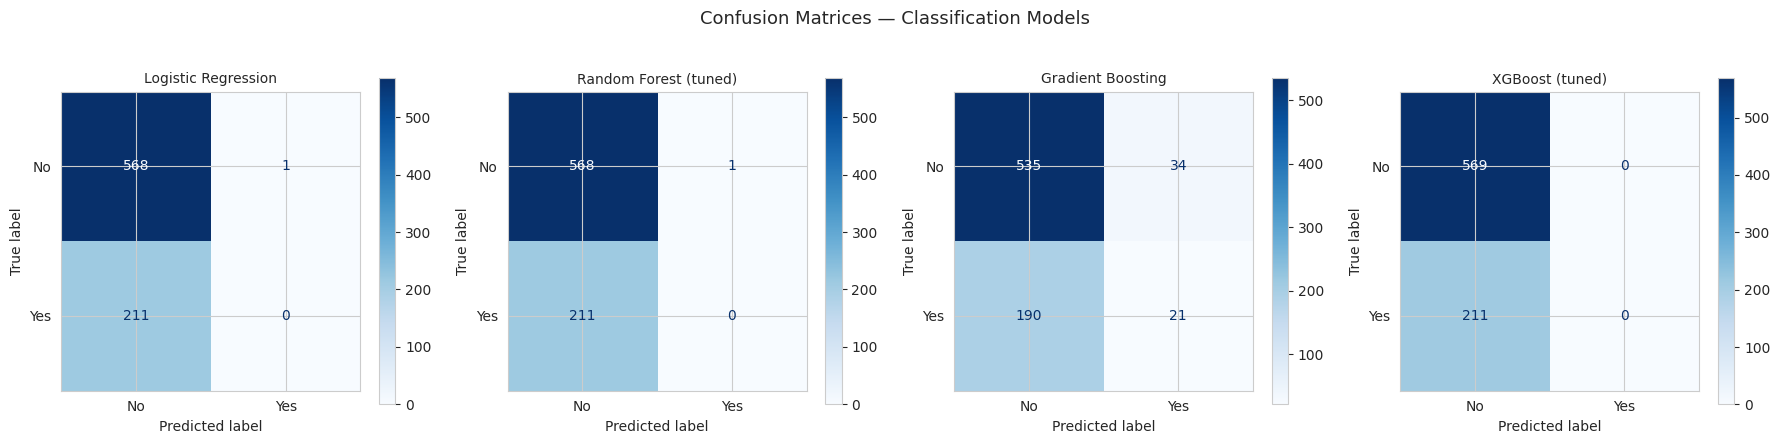

In [22]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, (name, pipeline) in enumerate(final_models.items()):
    y_pred = pipeline.predict(X_test_c)
    ConfusionMatrixDisplay.from_predictions(
        y_test_c, y_pred, ax=axes[i],
        display_labels=['No', 'Yes'],
        cmap='Blues'
    )
    axes[i].set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices — Classification Models', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

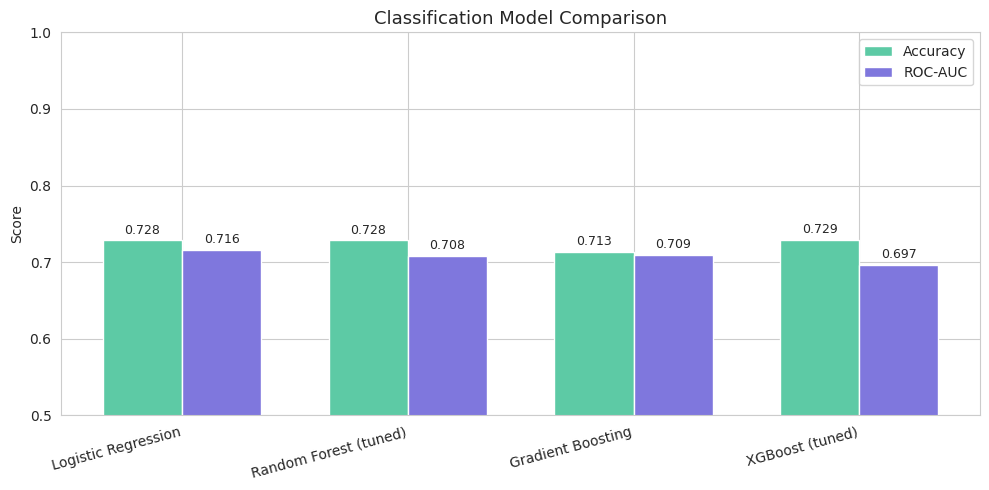

In [23]:
# Model comparison bar chart
results_df = pd.DataFrame(test_results).T
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='#5DCAA5')
bars2 = ax.bar(x + width/2, results_df['ROC-AUC'].astype(float), width, label='ROC-AUC', color='#7F77DD')

ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0.5, 1.0)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Task 2 — Regression: Predict Purchase Amount

### 6.1 Train/Test Split

In [24]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Train/Test Split — Regression:")
print(f"  Training: {X_train_r.shape[0]} samples")
print(f"  Testing:  {X_test_r.shape[0]} samples")
print(f"  Target stats (train): mean=${y_train_r.mean():.1f}, std=${y_train_r.std():.1f}")

Train/Test Split — Regression:
  Training: 3120 samples
  Testing:  780 samples
  Target stats (train): mean=$60.1, std=$23.7


### 6.2 Model Training with Cross-Validation

In [25]:
regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

from sklearn.model_selection import KFold
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 70)
print("5-FOLD CROSS-VALIDATION — Regression (Negative MAE)")
print("=" * 70)
print(f"{'Model':<25} {'Mean MAE':>10} {'Std MAE':>10} {'Mean R²':>10} {'Std R²':>10}")
print("-" * 70)

cv_reg_results = {}
for name, model in regression_models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor_t2),
        ('regressor', model)
    ])
    
    mae_scores = -cross_val_score(pipeline, X_train_r, y_train_r, cv=cv_reg, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(pipeline, X_train_r, y_train_r, cv=cv_reg, scoring='r2')
    
    cv_reg_results[name] = {'MAE': mae_scores.mean(), 'R2': r2_scores.mean()}
    print(f"{name:<25} {mae_scores.mean():>10.2f} {mae_scores.std():>10.2f} {r2_scores.mean():>10.4f} {r2_scores.std():>10.4f}")

print("\n⚠ EXPECTED FINDING: R² values near 0 indicate almost no predictive signal.")
print("  This confirms our EDA — Purchase Amount has no meaningful relationship")
print("  with the available features in this synthetic dataset.")

5-FOLD CROSS-VALIDATION — Regression (Negative MAE)
Model                       Mean MAE    Std MAE    Mean R²     Std R²
----------------------------------------------------------------------


Linear Regression              20.59       0.23    -0.0107     0.0061


Ridge Regression               20.59       0.23    -0.0106     0.0061
Lasso Regression               20.57       0.21    -0.0010     0.0006


Random Forest                  20.90       0.27    -0.0522     0.0178


Gradient Boosting              20.78       0.28    -0.0416     0.0057


XGBoost                        22.47       0.43    -0.2767     0.0310

⚠ EXPECTED FINDING: R² values near 0 indicate almost no predictive signal.
  This confirms our EDA — Purchase Amount has no meaningful relationship
  with the available features in this synthetic dataset.


### 6.3 Final Evaluation on Test Set

In [26]:
# Train and evaluate all regression models on test set
print("=" * 60)
print("FINAL TEST SET EVALUATION — Regression")
print("=" * 60)

reg_test_results = {}
for name, model in regression_models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor_t2),
        ('regressor', model)
    ])
    pipeline.fit(X_train_r, y_train_r)
    y_pred = pipeline.predict(X_test_r)
    
    mae = mean_absolute_error(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2 = r2_score(y_test_r, y_pred)
    
    reg_test_results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"\n{name}:")
    print(f"  MAE:  ${mae:.2f}")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  R²:   {r2:.4f}")

# Baseline comparison
baseline_mae = mean_absolute_error(y_test_r, [y_train_r.mean()] * len(y_test_r))
print(f"\n--- Baseline (predict mean=${y_train_r.mean():.0f}) ---")
print(f"  MAE: ${baseline_mae:.2f}")
print("\nIf models barely beat the baseline, there's no real signal to learn from.")

FINAL TEST SET EVALUATION — Regression

Linear Regression:
  MAE:  $20.74
  RMSE: $23.77
  R²:   -0.0099

Ridge Regression:
  MAE:  $20.74
  RMSE: $23.77
  R²:   -0.0098

Lasso Regression:
  MAE:  $20.76
  RMSE: $23.73
  R²:   -0.0064



Random Forest:
  MAE:  $21.05
  RMSE: $24.22
  R²:   -0.0483



Gradient Boosting:
  MAE:  $20.98
  RMSE: $24.08
  R²:   -0.0364

XGBoost:
  MAE:  $22.73
  RMSE: $27.14
  R²:   -0.3168

--- Baseline (predict mean=$60) ---
  MAE: $20.76

If models barely beat the baseline, there's no real signal to learn from.


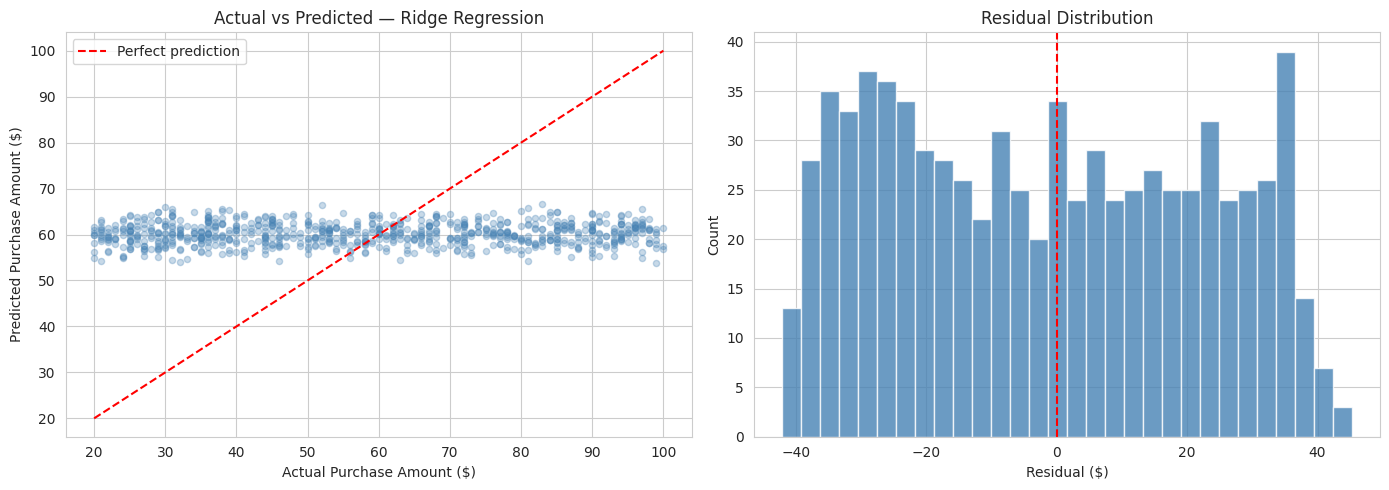

Residual stats: mean=$-1.93, std=$23.71


In [27]:
# Actual vs Predicted scatter for best regression model
best_reg_name = min(reg_test_results, key=lambda k: reg_test_results[k]['MAE'])
best_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor_t2),
    ('regressor', regression_models[best_reg_name])
])
best_reg_pipeline.fit(X_train_r, y_train_r)
y_pred_best = best_reg_pipeline.predict(X_test_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_r, y_pred_best, alpha=0.3, s=20, color='steelblue')
axes[0].plot([20, 100], [20, 100], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Purchase Amount ($)')
axes[0].set_ylabel('Predicted Purchase Amount ($)')
axes[0].set_title(f'Actual vs Predicted — {best_reg_name}', fontsize=12)
axes[0].legend()

# Residual distribution
residuals = y_test_r - y_pred_best
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Residual stats: mean=${residuals.mean():.2f}, std=${residuals.std():.2f}")

## 7. Model Interpretation

### 7.1 Feature Importance — Classification

Understanding *why* the model makes its predictions is as important as the predictions themselves.

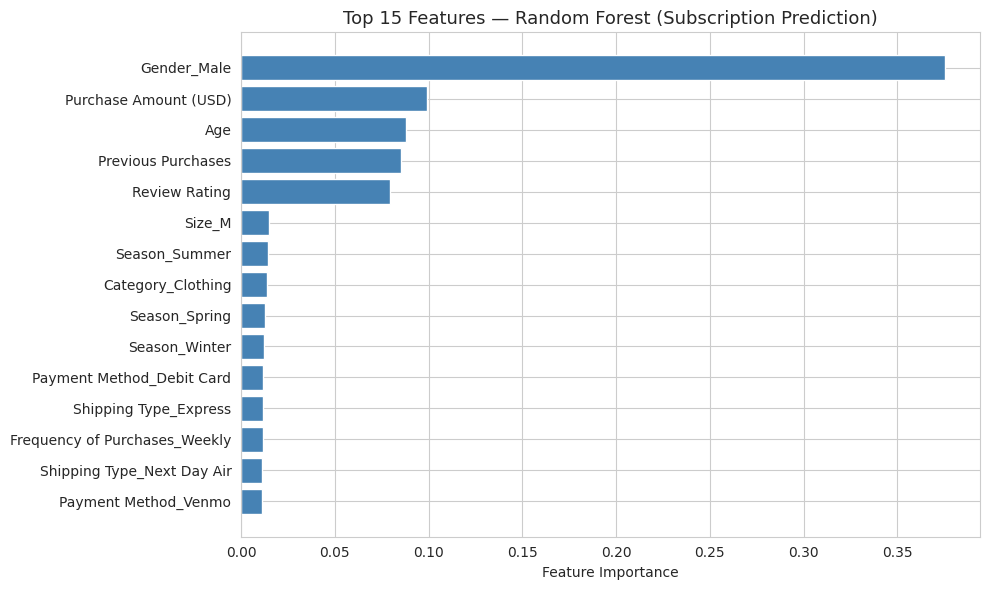

Top 5 most important features:
  Gender_Male: 0.3753
  Purchase Amount (USD): 0.0993
  Age: 0.0877
  Previous Purchases: 0.0852
  Review Rating: 0.0795


In [28]:
# Feature importance from the best classification model
# Use the tuned Random Forest
best_clf = rf_grid.best_estimator_

# Get feature names after preprocessing
feature_names = best_clf.named_steps['preprocessor'].get_feature_names_out()
# Clean up feature names
feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

importances = best_clf.named_steps['classifier'].feature_importances_

# Sort and plot top 15
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features — Random Forest (Subscription Prediction)', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

### 7.2 SHAP Analysis — Classification

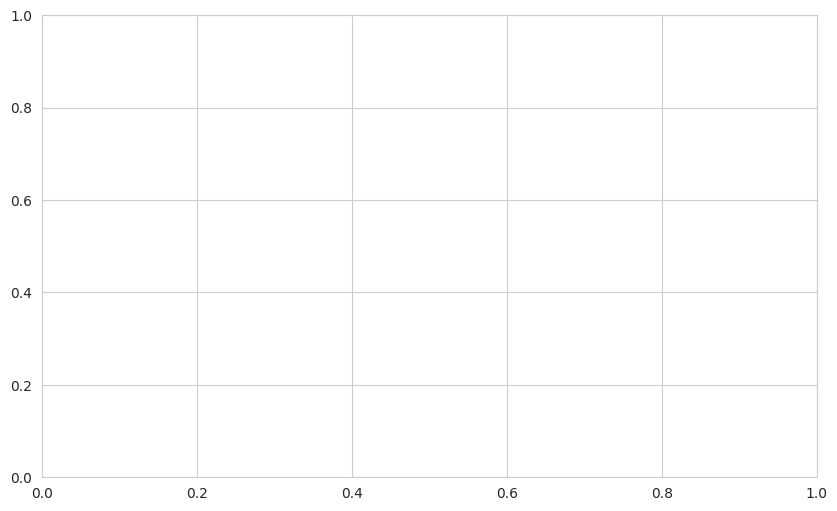

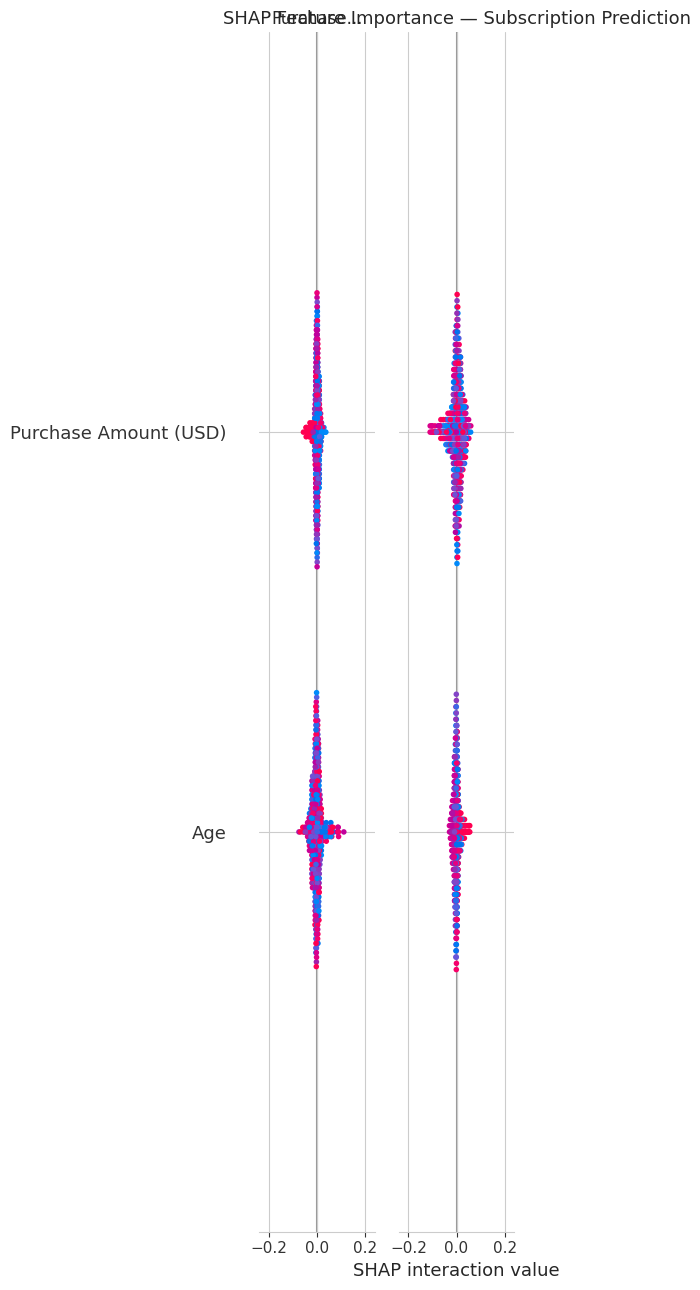


SHAP analysis shows which features push predictions toward
'subscriber' (positive SHAP) vs 'non-subscriber' (negative SHAP).


In [29]:
# SHAP values for model interpretability
# Transform data first
X_test_transformed = best_clf.named_steps['preprocessor'].transform(X_test_c)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Create SHAP explainer
explainer = shap.TreeExplainer(best_clf.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_df)

# For binary classification, use class 1 (subscriber) SHAP values
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# Summary plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test_df, max_display=15, show=False)
plt.title('SHAP Feature Importance — Subscription Prediction', fontsize=13)
plt.tight_layout()
plt.show()

print("\nSHAP analysis shows which features push predictions toward")
print("'subscriber' (positive SHAP) vs 'non-subscriber' (negative SHAP).")

## 8. Conclusions & Lessons Learned

### Key Findings

**Classification (Subscription Status):**
- Gender is the single dominant predictor — all Female customers are non-subscribers in this dataset.
- After Gender, the remaining features provide only marginal predictive power.
- The models achieve reasonable accuracy largely driven by this one strong signal.

**Regression (Purchase Amount):**
- R² values near 0 across all models confirm that none of the available features meaningfully predict purchase amount.
- This is expected: the purchase amount distribution is nearly uniform ($20–$100) with no relationship to demographics, product category, or purchase behavior.
- All models perform at or near the "predict the mean" baseline.

### Dataset Limitations

This dataset is **synthetic/generated**, as evidenced by:
1. Perfectly uniform distributions across almost all features
2. No missing values or duplicates (unrealistic for real e-commerce data)
3. Near-zero correlations between all features
4. Purchase amounts uniformly distributed with zero skew
5. Feature interactions (like `Discount Applied == Promo Code Used` being identical) that wouldn't occur naturally

### Methodology Improvements Over Previous Version

| Aspect | Previous Notebook | This Notebook |
|---|---|---|
| **Target variable** | Objective said regression, code did classification | Clear separation: two tasks with appropriate metrics |
| **Data leakage** | Item Purchased used to predict Category (1:1 mapping) | Item Purchased dropped; Discount Applied excluded from subscription prediction |
| **Encoding** | Single LabelEncoder reused across all columns | OneHotEncoder for nominal, proper pipeline |
| **Feature selection** | Done on full dataset before split | Implicit via pipeline (all processing inside CV folds) |
| **Validation** | Single train/test split | 5-fold stratified cross-validation |
| **Models** | Single model (Decision Tree or Random Forest) | 4–6 models compared systematically |
| **Tuning** | Default parameters only | GridSearchCV with multiple hyperparameter combinations |
| **Interpretation** | None | SHAP values + feature importance analysis |
| **Scaling** | None | StandardScaler inside pipeline |
| **Honesty** | 100% accuracy claimed as success | Acknowledged dataset limitations and weak signals |

### Recommendations for Future Work

1. **Use real data:** The UCI Online Retail II dataset (used in RetailIQ) provides genuine patterns with messy, realistic data.
2. **Feature engineering:** Create derived features like customer lifetime value, purchase frequency ratios, and recency scores.
3. **Advanced models:** Try neural networks, ensemble stacking, or time-series approaches for real datasets.
4. **Deployment:** Build a simple API endpoint (FastAPI) to serve predictions.

> **The most important lesson:** A 100% accuracy score should trigger suspicion, not celebration. 
> If your model is perfect, you almost certainly have data leakage — not a great model.